# Machine Learning: Volatility Forecasting

## Introduction
prob, sol, methods, imple

### Imports

In [1]:
import src.paths as paths
import src.volatility as volatility
import src.machine_learning as ml
import src.feature_engineering as fe
from src.data import load_data
import run_updates

from arch import arch_model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import importlib
importlib.reload(ml)

<module 'src.machine_learning' from 'c:\\Users\\jspit\\OneDrive\\Documents\\personal projects\\Machine Learning Fin\\src\\machine_learning.py'>

# Data

Daily OHLCV data is obtained from yfinance and FRED, and is used to construct the volatility target and endogenous features. VIX is incorporated as an exogneous measure of overall market volatility.

The analysis uses BTC.

Data is loaded through the project's data pipeline which handles retrieval, caching, cleaning, and alignment.

Run this first to fetch the latest stock/market data.

In [2]:
run_updates.main()

Loaded and processed: commodities (10 items)
Loaded and processed: crypto (29 items)
Loaded and processed: macro (31 items)
Loaded and processed: equities (15 items)
Loaded and processed: forex (6 items)
Loaded and processed: indices (24 items)
Starting update run...

[commodities]
completed: 10 updated, 0 skipped, 0 failed
saved rows=6722 cols=50 range=2000-01-03 to 2026-09-08

[crypto]
completed: 29 updated, 0 skipped, 0 failed
saved rows=4375 cols=145 range=2014-09-17 to 2026-09-08

[macro]
Unsupported source: Scrape
completed: 30 updated, 1 skipped, 0 failed
saved rows=17687 cols=34 range=1913-01-01 to 2026-09-08

[equities]
completed: 15 updated, 0 skipped, 0 failed
saved rows=16279 cols=75 range=1962-01-02 to 2026-09-08

[forex]
completed: 6 updated, 0 skipped, 0 failed
saved rows=14141 cols=30 range=1971-01-04 to 2026-09-08

[indices]
completed: 24 updated, 0 skipped, 0 failed
saved rows=25306 cols=120 range=1927-12-30 to 2026-09-08

Run complete
updated=114 skipped=1 failed=0
l

Load the data to be used in the analysis

In [3]:
asset = 'BTC'

ohlcv = load_data(paths.CRYPTO_DATA_PARQUET, '1d')
asset_ohlcv = ohlcv[asset].dropna()

asset_ohlcv.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-04,79671.968750,81433.148438,78641.625000,81271.539062,3.750187e+10
2026-09-05,79823.867188,80194.507812,79465.062500,79671.703125,1.855971e+10
2026-09-06,80350.046875,80530.648438,79327.500000,79824.601562,1.939186e+10
2026-09-07,79115.851562,80432.312500,78684.929688,80349.195312,2.341443e+10
2026-09-08,78505.492188,79455.585938,77782.703125,79093.851562,3.384348e+10


# Volatility Measure

Parkinson Volatility is used to estimate the daily volatility. This measure uses daily high and low prices to incorporate information about intraday variation, providing a better estimate than Realised Absolute Volume which only uses close-to-close prices. Parkinson volatility is a good estimate for 24/7 markets, however it does not account for overnight volatility and price jumps - a weakness when it comes to typical stock market data. To address this, the Yang-Zhang volatility estimator could be implemented for stock market data.

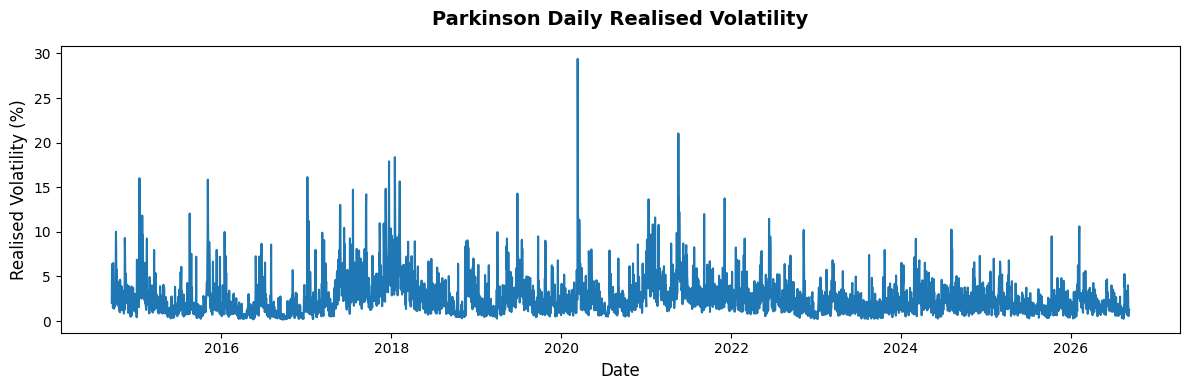

In [4]:
realised_vol = volatility.parkinson_vol(asset_ohlcv)


plt.figure(figsize=(12, 4)) 
plt.plot(realised_vol)
plt.title('Parkinson Daily Realised Volatility', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Realised Volatility (%)', fontsize=12)
plt.tight_layout()
plt.show()


# Volatility Forecast Benchmarks

### GARCH(1,1)
Statistical formula used to forecast time-varying volatility that combines the long-term baseline, recent market shocks and past volatility. Taken over 500-day rolling window (i.e. use T-500 to predict T).

### Naive Persistent
Simplest possible forecast, predicts tomorrow's volatility as today's value.

### Naive Rolling Average
Smooths the variance of the Naive Persistent forecast, accounts for previous short-term history and shocks.

In [5]:
garch_forecast = volatility.garch_forecast(asset_ohlcv['Close'], 500)
naive_persistent_forecast = volatility.naive_persistent_forecast(realised_vol)
naive_rolling_avg_forecast = volatility.naive_avg_forecast(realised_vol, 21)

forecasts = {
    'GARCH(1,1)': garch_forecast,
    'Naive (persistence)': naive_persistent_forecast,
    'Naive (rolling avg)': naive_rolling_avg_forecast
}

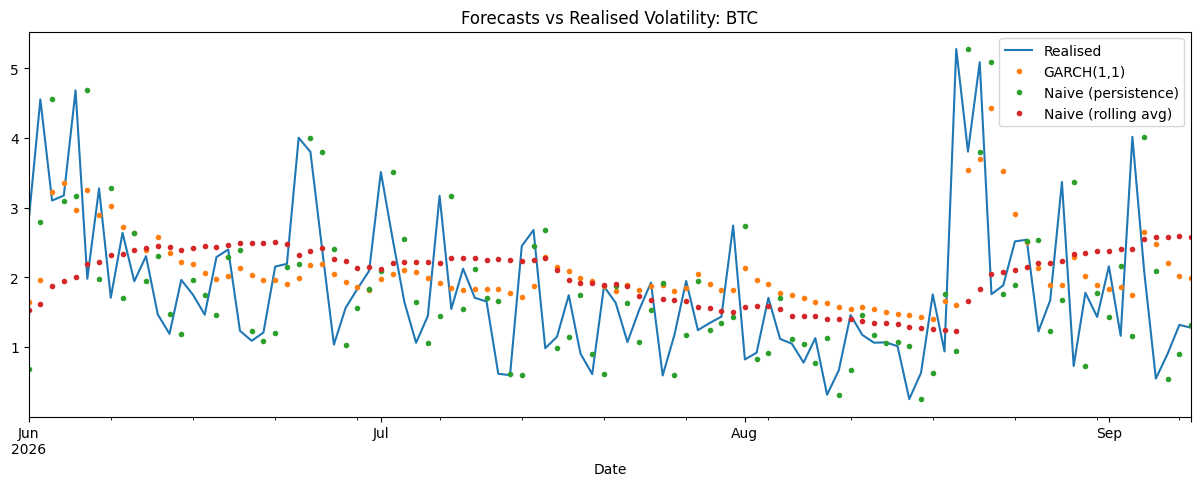

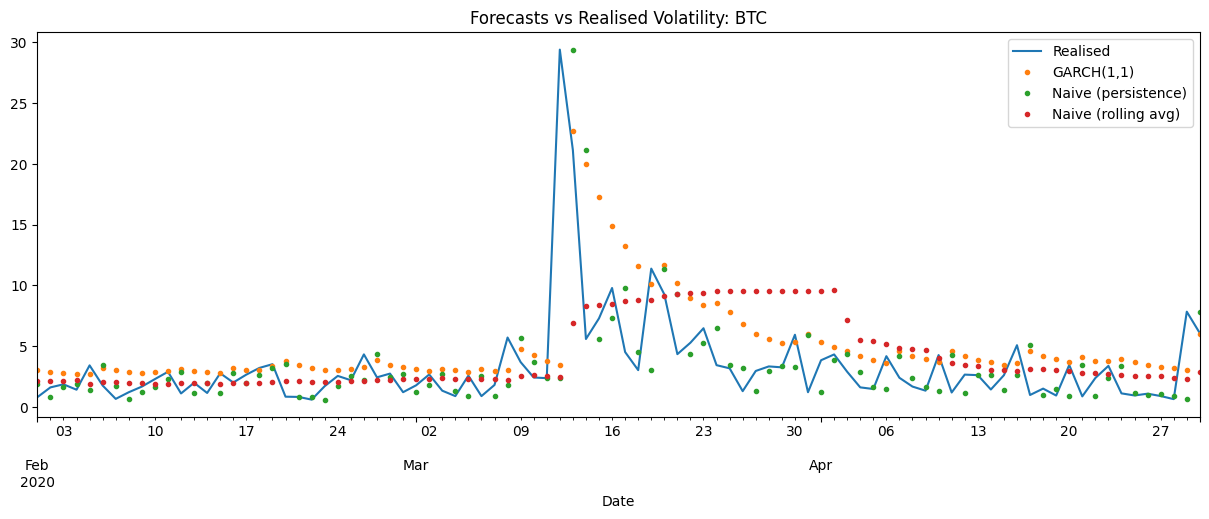

In [6]:
recent = ml.filter_forecasts(forecasts, '2026-06-01', '2026-09-08')
covid = ml.filter_forecasts(forecasts, '2020-02-01', '2020-04-30')

ml.plot_predictions_vs_realised(realised_vol, recent, asset)
ml.plot_predictions_vs_realised(realised_vol, covid, asset)

# Feature Engineering

The model uses both endogenous and exogenous volatility information

### (Lagged) Volatility

### (Lagged) Returns

### Moving Averages

### VIX

In [7]:
features = fe.build_ml_features(asset_ohlcv)

features.tail()

Price,Close,High,Low,Open,Volume,Parkinson,VIX_0,Realised_vol_0,Returns_0,VIX_1,...,Price_vs_sma21,Price_vs_sma50,Price_vs_sma200,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-04,79671.968750,81433.148438,78641.625000,81271.539062,3.750187e+10,2.094834,14.32,4.016221,0.050098,15.20,...,1.095053,1.187166,1.168231,4,3,9,2026,247,4,36
2026-09-05,79823.867188,80194.507812,79465.062500,79671.703125,1.855971e+10,0.548767,14.53,2.094834,-0.019881,14.32,...,1.062119,1.158422,1.144345,5,3,9,2026,248,5,36
2026-09-06,80350.046875,80530.648438,79327.500000,79824.601562,1.939186e+10,0.904024,14.53,0.548767,0.001905,14.53,...,1.052915,1.155281,1.145512,6,3,9,2026,249,6,36
2026-09-07,79115.851562,80432.312500,78684.929688,80349.195312,2.341443e+10,1.319093,14.53,0.904024,0.006570,14.53,...,1.048312,1.157685,1.151912,0,3,9,2026,250,7,37
2026-09-08,78505.492188,79455.585938,77782.703125,79093.851562,3.384348e+10,1.277941,15.30,1.319093,-0.015479,14.53,...,1.022925,1.135184,1.133231,1,3,9,2026,251,8,37


In [8]:
features.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Parkinson', 'VIX_0',
       'Realised_vol_0', 'Returns_0', 'VIX_1', 'Realised_vol_1', 'Returns_1',
       'VIX_2', 'Realised_vol_2', 'Returns_2', 'VIX_5', 'Realised_vol_5',
       'Returns_5', 'VIX_10', 'Realised_vol_10', 'Returns_10', 'VIX_20',
       'Realised_vol_20', 'Returns_20', 'VIX_60', 'Realised_vol_60',
       'Returns_60', 'VIX_120', 'Realised_vol_120', 'Returns_120', 'Vol_7_sma',
       'Vol_7_ema', 'Price_7_sma', 'Price_7_ema', 'Normalised_Volume_sma7',
       'Normalised_Volume_ema7', 'Vol_14_sma', 'Vol_14_ema', 'Price_14_sma',
       'Price_14_ema', 'Normalised_Volume_sma14', 'Normalised_Volume_ema14',
       'Vol_21_sma', 'Vol_21_ema', 'Price_21_sma', 'Price_21_ema',
       'Normalised_Volume_sma21', 'Normalised_Volume_ema21', 'Vol_50_sma',
       'Vol_50_ema', 'Price_50_sma', 'Price_50_ema', 'Normalised_Volume_sma50',
       'Normalised_Volume_ema50', 'Vol_200_sma', 'Vol_200_ema',
       'Price_200_sma', 'Price_200_ema'

# XGBoost Model

### Train/Test Split
As volatilty is a time series, the data is split by date (here arbitrarily chosen as 2024-01-01). The model is trained on the data before split_date and evaluated on its forecasts after split_date to avoid leakage. The training data is further split into "train" and "eval" 80:20 chronologically. The "eval" data is used by XGBoost to monitor its performance during training, alongside early stopping, to optimise boosting, prevent overfitting, and improve generalisability.

### XGBoost


| Parameter | Value | Rationale |
| :--- | :--- | :--- |
| **Max depth** | 3 | Limit model complexity |
| **Learning rate** | 0.01 | Gradual boosting |
| **Estimators** | 1000 | Upper bound with early stopping |
| **Early stopping** | 50 | Prevent unnecessary iterations |

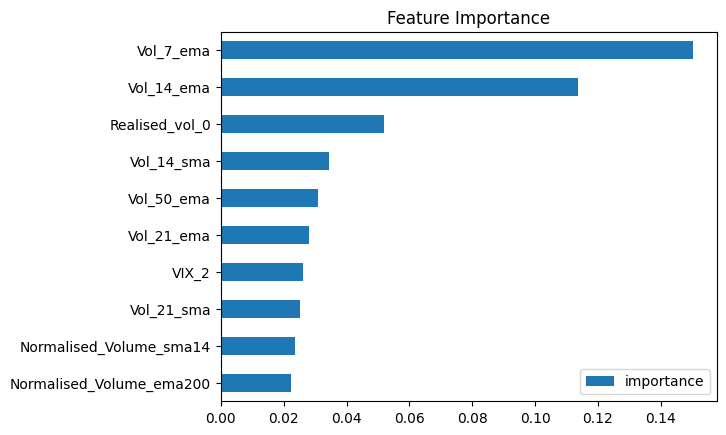

In [21]:
train_data, test_data = ml.split_train_test(features, split_date='2024-01-01')
model = ml.train_model(train_data)

ml.plot_feature_importance(model, 10)

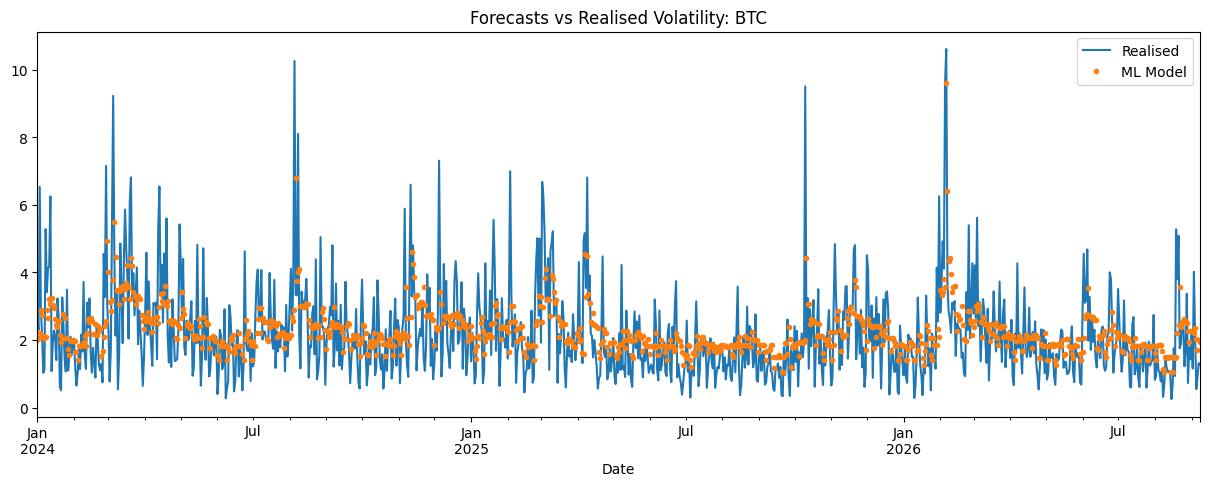

In [13]:
model_forecast = ml.forecast_model(test_data, model)

forecast = {'ML Model': model_forecast}

ml.plot_predictions_vs_realised(realised_vol, forecast, asset)

In [15]:
forecasts = {
    'GARCH(1,1)': garch_forecast,
    'Naive (persistence)': naive_persistent_forecast,
    'Naive (rolling avg)': naive_rolling_avg_forecast,
    'ML Model': model_forecast,
}

results = ml.compare_forecasts(forecasts, realised_vol)

df = pd.DataFrame(results).T.round(4)
print(df)

                      qlike       mse     mae
GARCH(1,1)           0.5794   91.7851  5.0747
Naive (persistence)  1.2770  135.8054  6.0044
Naive (rolling avg)  0.6369  100.0051  5.3488
ML Model             0.5021   78.7709  4.4202


# Walk-Forward Validation



In [16]:
results_per_block, results_combined, forecasts = ml.run_walk_forward_comparison(asset_ohlcv)

In [17]:
df = pd.DataFrame(results_combined).T.round(4)
print(df)

                          qlike       mse      mae
GARCH(1,1)               0.8019  676.3124  10.8730
Naive (persistence)      1.9161  836.4914  10.4492
Naive (rolling avg)      1.0047  740.7963  11.4959
ML Model (Walk-Forward)  0.8274  655.7833   8.6030


Model   GARCH(1,1)  ML Model  Naive (persistence)  Naive (rolling avg)
mean        0.8054    0.8290               1.9157               1.0065
std         0.3283    0.4882               1.2873               0.4291
median      0.6644    0.6532               1.4601               0.9048
min         0.3831    0.3007               0.6744               0.4055
max         1.5791    2.7174               6.6931               2.0424


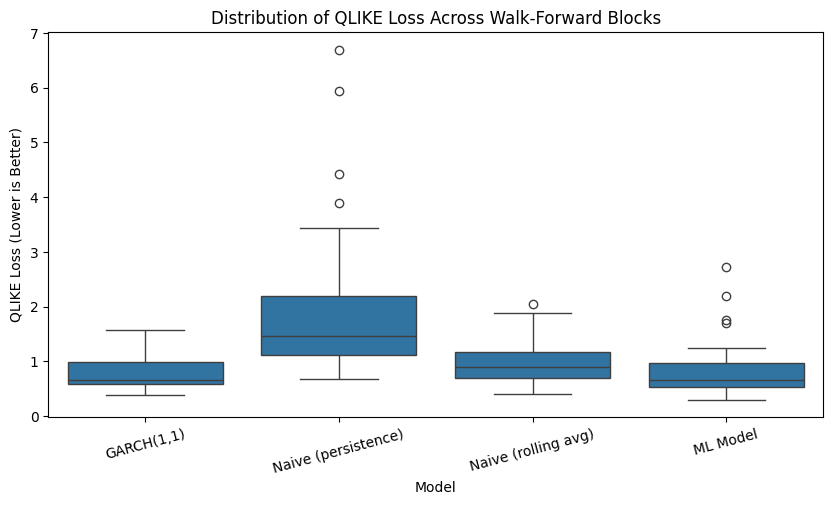

In [18]:
rows = []
for block, models in results_per_block.items():
    for model, metrics in models.items():
        row = {'Block': block, 'Model': model}
        row.update(metrics)
        rows.append(row)

df = pd.DataFrame(rows)

summary_stats = df.groupby('Model')[['qlike', 'mse', 'mae']].agg(['mean', 'std', 'median', 'min', 'max'])
summary_stats = summary_stats.round(4)

print(summary_stats['qlike'].T)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.reset_index(), x='Model', y='qlike')
plt.title('Distribution of QLIKE Loss Across Walk-Forward Blocks')
plt.ylabel('QLIKE Loss (Lower is Better)')
plt.xticks(rotation=15)
plt.show()


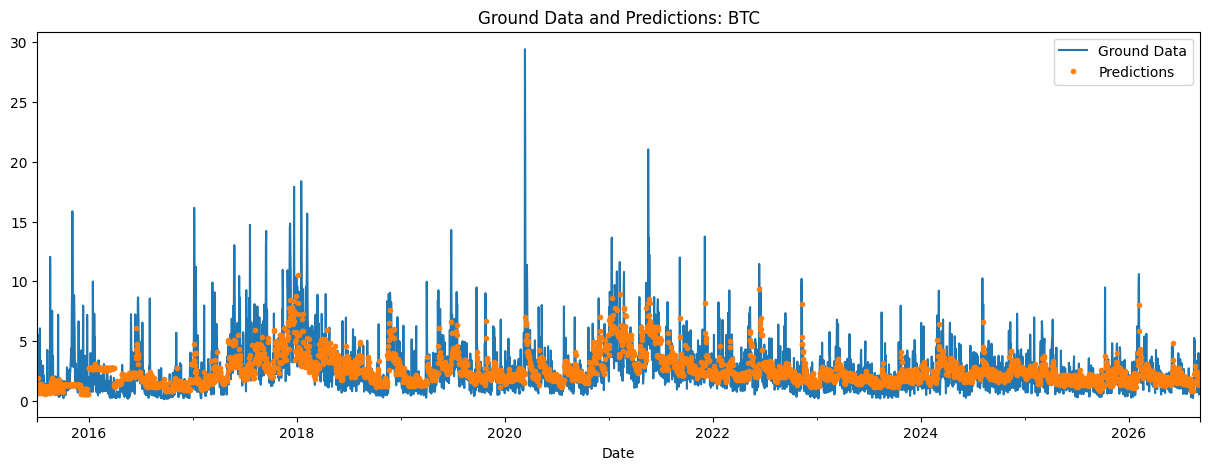

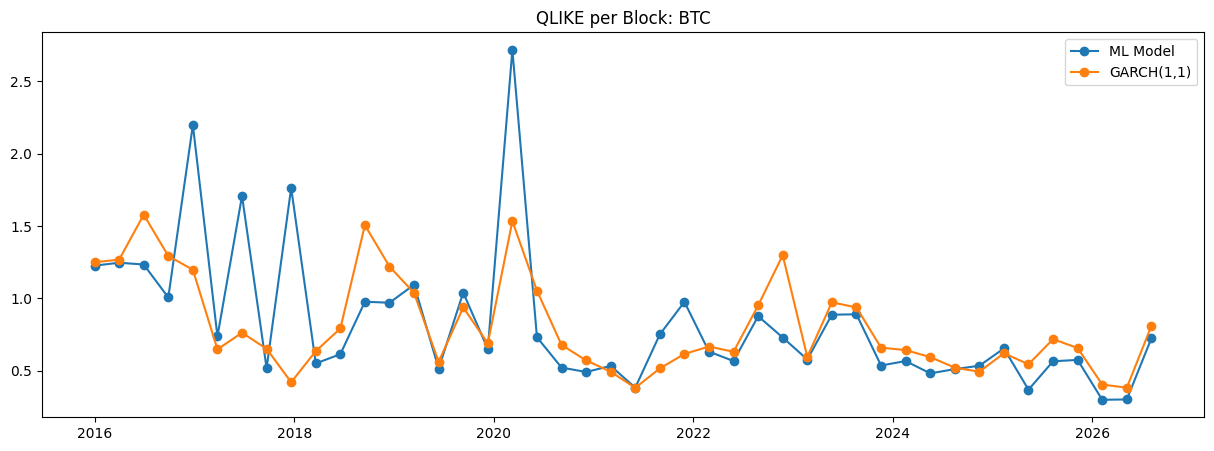

In [19]:
ml.plot_walk_forward(realised_vol, forecasts, results_per_block, asset)